# Entrenamiento para que reconozca que es otro objeto y no lo confunda con bloqueos

In [10]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from pathlib import Path
import copy
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [9]:

DESTINO = Path.cwd().parents[0] / "dataset"/"dataset_otros"

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(DESTINO / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(DESTINO / "val", transform=val_tf)
test_ds = datasets.ImageFolder(DESTINO / "test", transform=val_tf)

print("Clases:", train_ds.classes)  
test_loader = DataLoader(test_ds, batch_size=32, num_workers=2)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, num_workers=2)


Clases: ['calle', 'otros']


In [8]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)
model_otros = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_otros.parameters():
    param.requires_grad = False
model_otros.fc = nn.Linear(model_otros.fc.in_features, 2)
model_otros = model_otros.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_otros.fc.parameters(), lr=1e-3)

best_val_acc = 0.0
best_weights = None

for epoch in range(10):
    model_otros.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model_otros(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

    model_otros.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model_otros(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    print(f"Epoch {epoch+1}: val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model_otros.state_dict())

model_otros.load_state_dict(best_weights)
torch.save(model_otros.state_dict(), "modelo_detector_calle.pth")
print(f"Mejor val_acc: {best_val_acc:.4f}")

Usando: cuda


/home/jessihdd/SCESI/CursoIA/Deteccion-Bloqueos/.venv/lib/python3.11/site-packages/PIL/Image.py:3578: DecompressionBombWarning: Image size (121500000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 1: val_acc=0.9459


/home/jessihdd/SCESI/CursoIA/Deteccion-Bloqueos/.venv/lib/python3.11/site-packages/PIL/Image.py:3578: DecompressionBombWarning: Image size (121500000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 2: val_acc=0.9550


...

Epoch 8: val_acc=0.9691


/home/jessihdd/SCESI/CursoIA/Deteccion-Bloqueos/.venv/lib/python3.11/site-packages/PIL/Image.py:3578: DecompressionBombWarning: Image size (121500000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 9: val_acc=0.9640


/home/jessihdd/SCESI/CursoIA/Deteccion-Bloqueos/.venv/lib/python3.11/site-packages/PIL/Image.py:3578: DecompressionBombWarning: Image size (121500000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 10: val_acc=0.9653
Mejor val_acc: 0.9691


In [11]:
model_otros.eval()
preds_all, labels_all = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model_otros(imgs)
        preds = out.argmax(1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

preds_all = np.array(preds_all)
labels_all = np.array(labels_all)

acc = (preds_all == labels_all).mean()
print(f"Accuracy en test: {acc:.4f}\n")

print(classification_report(labels_all, preds_all, target_names=test_ds.classes))

Accuracy en test: 0.9745

              precision    recall  f1-score   support

       calle       0.98      0.99      0.98       561
       otros       0.97      0.94      0.95       224

    accuracy                           0.97       785
   macro avg       0.97      0.96      0.97       785
weighted avg       0.97      0.97      0.97       785



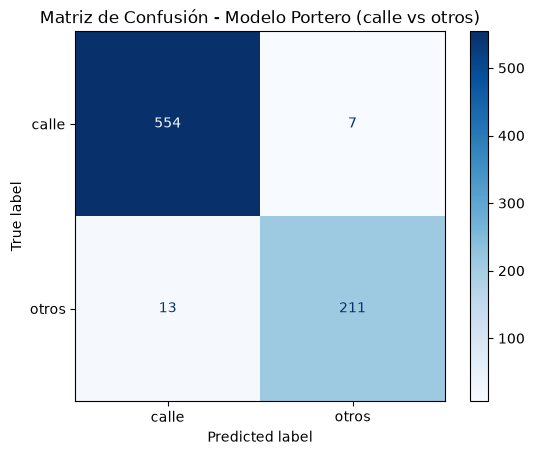

In [12]:
cm = confusion_matrix(labels_all, preds_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_ds.classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Modelo Portero (calle vs otros)")
plt.show()